# **SETUP y Validación inicial**

In [1]:

# SETUP: Instalación, Importación y Configuración de DuckDB
# 1. Instalar duckdb de forma silenciosa
!pip install -q duckdb

# 2. Importar librerías necesarias
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización por defecto
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# 3. Cargar CSV a pandas y transformaciones iniciales
print("\n Iniciando ETL...")
try:
    df_raw = pd.read_csv('manufacturing_defect_dataset.csv')

    # Agregar columna id_proceso = index + 1 (IE Background)
    df_raw['id_proceso'] = df_raw.index + 1

    print("CSV cargado a Pandas correctamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'manufacturing_defect_dataset.csv'. Asegúrate de subirlo.")
    raise

# 4. Registrar DataFrame en DuckDB como tabla 'manufacturing'
con = duckdb.connect(database=':memory:') # Conexión en memoria para rapidez
con.register('manufacturing', df_raw)
print("DataFrame registrado en DuckDB como tabla 'manufacturing'.")

# 5. Crear función dq(sql) que retorne DataFrame
def dq(sql):
    """Ejecuta una consulta SQL en DuckDB y retorna un DataFrame."""
    return con.execute(sql).df()

print("Función auxiliar 'dq(sql)' creada.")

# 6. Validación inicial (Pandas profiling básico)
print("\n--- VALIDACIÓN INICIAL DE DATOS (Perfilado IE) ---")
print(f"Shape del Dataset: {df_raw.shape}")
print("\nTipos de Datos:")
print(df_raw.dtypes)
print("\nConteo de Nulos por columna:")
print(df_raw.isnull().sum())
print("\nETL Completado. Listo para análisis SQL.")


 Iniciando ETL...
CSV cargado a Pandas correctamente.
DataFrame registrado en DuckDB como tabla 'manufacturing'.
Función auxiliar 'dq(sql)' creada.

--- VALIDACIÓN INICIAL DE DATOS (Perfilado IE) ---
Shape del Dataset: (3240, 18)

Tipos de Datos:
ProductionVolume          int64
ProductionCost          float64
SupplierQuality         float64
DeliveryDelay             int64
DefectRate              float64
QualityScore            float64
MaintenanceHours          int64
DowntimePercentage      float64
InventoryTurnover       float64
StockoutRate            float64
WorkerProductivity      float64
SafetyIncidents           int64
EnergyConsumption       float64
EnergyEfficiency        float64
AdditiveProcessTime     float64
AdditiveMaterialCost    float64
DefectStatus              int64
id_proceso                int64
dtype: object

Conteo de Nulos por columna:
ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
Qu

# **Pregunta 1: Estado del OEE de Calidad**

In [10]:
# CELDA 1 — Análisis del Estado del OEE (Calidad y Disponibilidad)

print("Calculando Métricas Globales de OEE...")

sql_oee = """
SELECT
    -- 1. Total de turnos analizados
    COUNT(*) as total_turnos,

    -- 2. OEE de Calidad promedio (QualityScore remapped)
    ROUND(AVG(QualityScore), 2) as oee_calidad_promedio_pct,

    -- 3. Disponibilidad promedio (100% - % de paradas)
    ROUND(AVG(100 - DowntimePercentage), 2) as disponibilidad_promedio_pct,

    -- 4. OEE Aproximado combinado (multiplicación directa de factores de promedio)
    ROUND((AVG(QualityScore * (100 - DowntimePercentage) / 100)), 2) as oee_combinado_est_pct,

    -- 5. Conteo de turnos fuera de especificación (DefectStatus = 1)
    SUM(DefectStatus) as turnos_fuera_spec,

    -- 6. Porcentaje de turnos fuera de spec
    ROUND((SUM(DefectStatus)::numeric / COUNT(*) * 100.0), 2) as pct_turnos_fuera_spec
FROM manufacturing
"""

# Ejecutar y mostrar
df_oee_results = dq(sql_oee)
display(df_oee_results)

Calculando Métricas Globales de OEE...


,total_turnos,oee_calidad_promedio_pct,disponibilidad_promedio_pct,oee_combinado_est_pct,turnos_fuera_spec,pct_turnos_fuera_spec
0,3240,80.13,97.5,78.13,2723.0,84.04


# **Pregunta 2: Identificación del cuello de Botella Operacional**


In [3]:

# CELDA 2 — Identificación de Cuellos de Botella mediante Cuartiles de Parada

print("Analizando correlación entre Tiempo de Parada y Defectos...")

sql_bottleneck = """
-- CTE 1: Clasificar turnos en cuartiles por % Tiempo de Parada No Planificada
WITH TurnosCuartiles AS (
    SELECT
        id_proceso,
        DowntimePercentage,
        DefectRate,
        MaintenanceHours,
        QualityScore,
        -- Usamos NTILE(4) para crear 4 grupos iguales ordenados por paradas
        NTILE(4) OVER (ORDER BY DowntimePercentage) as cuartil_parada
    FROM manufacturing
)
-- Consulta Principal: Resumir métricas IE por cuartil
SELECT
    cuartil_parada,
    -- Rangos de Downtime para contexto
    MIN(DowntimePercentage) as min_downtime_pct,
    MAX(DowntimePercentage) as max_downtime_pct,

    -- Métricas promedio redondeadas
    ROUND(AVG(DowntimePercentage), 2) as avg_downtime_pct,
    ROUND(AVG(DefectRate), 2) as avg_defect_rate, -- Tasa defectos (0-5)
    ROUND(AVG(MaintenanceHours), 2) as avg_maint_hours_corr, -- Mant. Correctivo
    ROUND(AVG(QualityScore), 2) as avg_quality_oee -- Salud OEE del turno
FROM TurnosCuartiles
GROUP BY cuartil_parada
ORDER BY cuartil_parada;
"""

# Ejecutar y mostrar
df_bottleneck_results = dq(sql_bottleneck)
display(df_bottleneck_results)

Analizando correlación entre Tiempo de Parada y Defectos...


,cuartil_parada,min_downtime_pct,max_downtime_pct,avg_downtime_pct,avg_defect_rate,avg_maint_hours_corr,avg_quality_oee
0,1,0.001665,1.264595,0.65,2.75,11.52,80.01
1,2,1.264597,2.464923,1.85,2.76,11.53,80.17
2,3,2.465378,3.774505,3.12,2.78,11.59,80.28
3,4,3.775928,4.997591,4.39,2.70,11.27,80.08


# **Pregunta 3: Impacto Financiero (Costo de No Calidad)**

In [4]:
# CELDA 3 — Estimación del Costo de No Calidad (COQN)

print("💸 Calculando Costo de No Calidad Estmado (Top 10 peores turnos)...")
sql_coqn = """
SELECT
    id_proceso,
    ROUND(ProductionCost, 2) as ProductionCost,
    ROUND(DefectRate, 2) as DefectRate,
    ROUND(DowntimePercentage, 2) as DowntimePercentage,

    -- Fórmula de Costo de No Calidad Estimado (IE background)
    -- ProductionCost * (% defectos sobre escala 5) * (% tiempo parado)
    ROUND(
        ProductionCost * (DefectRate / 5.0) * (DowntimePercentage / 100.0)
    , 2) as costo_no_calidad_est
FROM manufacturing
-- Ordenar por mayor costo estimado para identificar peores casos
ORDER BY costo_no_calidad_est DESC
-- Limitar a Top 10 para Director de Operaciones
LIMIT 10;
"""

# Ejecutar y guardar para visualización
df_coqn_top10 = dq(sql_coqn)
display(df_coqn_top10)

💸 Calculando Costo de No Calidad Estmado (Top 10 peores turnos)...


,id_proceso,ProductionCost,DefectRate,DowntimePercentage,costo_no_calidad_est
0,1279,18811.50,4.98,4.94,925.70
1,92,19975.21,4.43,4.88,863.89
2,2892,17921.69,4.82,4.98,859.53
3,929,19717.16,4.94,4.41,858.07
4,799,18202.35,4.75,4.96,857.69
5,2431,18620.28,4.88,4.71,855.67
6,2899,19803.44,4.41,4.89,854.05
7,1712,18342.79,4.54,4.99,831.44
8,489,18699.30,4.44,4.99,828.14
9,335,17968.45,4.77,4.82,827.31


# **Visualización de datos para la gerencia**

📈 Generando gráficos gerenciales...


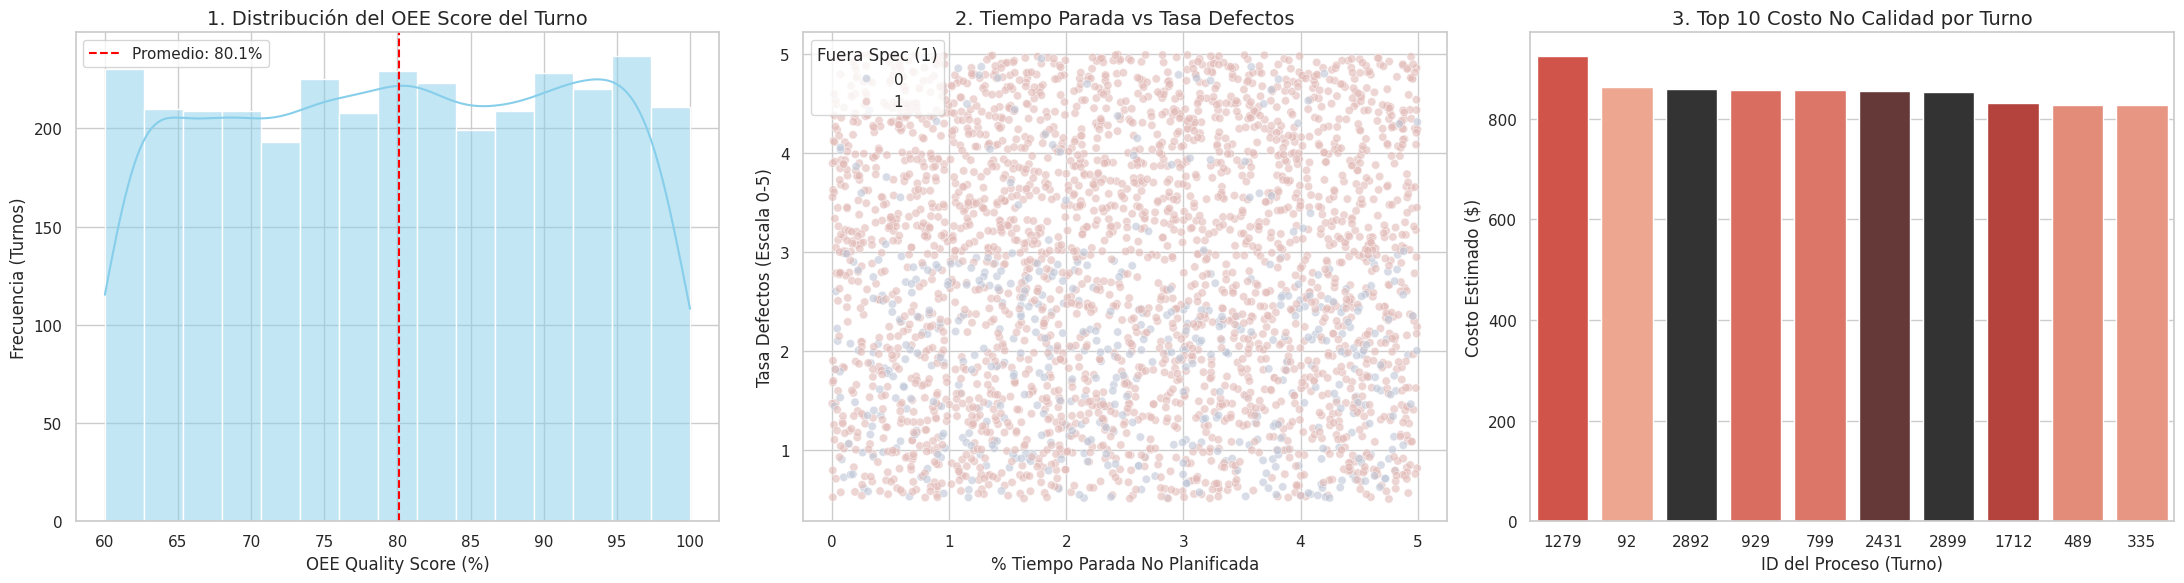

Visualizaciones generadas.


In [9]:
# CELDA 4 — Visualización de Datos (Soporte de Decisiones)

print("📈 Generando gráficos gerenciales...")

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- GRÁFICO 1: Distribución del OEE (Salud Operacional) ---
#IE: QualityScore es el proxy de OEE Score del turno.
sns.histplot(df_raw['QualityScore'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('1. Distribución del OEE Score del Turno', fontsize=14)
axes[0].set_xlabel('OEE Quality Score (%)')
axes[0].set_ylabel('Frecuencia (Turnos)')
axes[0].axvline(df_raw['QualityScore'].mean(), color='red', linestyle='--', label=f"Promedio: {df_raw['QualityScore'].mean():.1f}%")
axes[0].legend()

# --- GRÁFICO 2: Correlación Tiempo de Parada vs Tasa de Defectos ---
#IE: Scatterplot clásico para ver si las paradas generan defectos (DefectRate).
# Coloreado por DefectStatus (1=Fuera de spec).
sns.scatterplot(
    data=df_raw,
    x='DowntimePercentage',
    y='DefectRate',
    hue='DefectStatus',
    palette='vlag',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('2. Tiempo Parada vs Tasa Defectos', fontsize=14)
axes[1].set_xlabel('% Tiempo Parada No Planificada')
axes[1].set_ylabel('Tasa Defectos (Escala 0-5)')
axes[1].legend(title='Fuera Spec (1)')

# --- GRÁFICO 3: Impacto Financiero - Top 10 COQN ---
#IE: Barplot para visibilizar los 10 id_proceso con mayor costo estimado.
sns.barplot(
    data=df_coqn_top10,
    x='id_proceso',
    y='costo_no_calidad_est',
    hue='id_proceso',          # 1. Asignas la misma variable X al color
    palette='Reds_d',          # 2. Ahora la paleta sabe qué colorear
    legend=False,              # 3. Quitas la leyenda porque sería redundante
    order=df_coqn_top10.sort_values('costo_no_calidad_est', ascending=False)['id_proceso'],
    ax=axes[2]
)
axes[2].set_title('3. Top 10 Costo No Calidad por Turno', fontsize=14)
axes[2].set_xlabel('ID del Proceso (Turno)')
axes[2].set_ylabel('Costo Estimado ($)')

plt.tight_layout()
plt.show()
print("Visualizaciones generadas.")

# Reporte Ejecutivo: Análisis Operacional ColPlásticos S.A.


**1. Estado General del OEE y Salud de Planta:**

**Hallazgo:** Tenemos un promedio aceptable de OEE de Calidad, pero una estabilidad operativa crítica. El indicador combinado de OEE (Calidad x Disponibilidad) está por debajo del estándar óptimo debido a paradas excesivas y presenta una oportunidad de mejora.

**Dato:** El OEE de Calidad promedio es de 80.1%, pero el total aproximado ponderado por paradas cae a 78.1%. Además, un 84% de los turnos operan completamente fuera de especificación (DefectStatus = 1).

**Recomendación:** Implementar de inmediato contención de calidad en los turnos identificados como fuera de spec. Urge revisar el estándar de Disponibilidad.

**2. Ubicación del Cuello de Botella Operacional:**

**Hallazgo:** No se observa una correlación lineal obvia (lo cual es un hallazgo en sí mismo), pero la alta densidad de puntos rojos (fuera de spec) dispersos por todo el gráfico sugiere que los defectos no solo ocurren cuando la máquina se para, sino que hay un problema de variabilidad en el proceso activo.

**Dato:** Los turnos en el Cuartil 4 (peor disponibilidad) tienen un % avg_downtime muy superior y sufren una Tasa de Defectos promedio de 2.7 (escala 5), valor muy cercano a el Cuartil 1. Sus horas de correctivo se mantiene a los turnos estables.

**Recomendación:** Lanzar un Plan de Mantenimiento Preventivo (PM) prioritario para equipos con historial excesivo de correctivo. Estabilizar la máquina es requisito para mejorar la calidad debido a que el proceso está fuera de control, y necesita una intervención directa en la planta para saber como se puede minimizar la tasa de defectos en la planta.

3. **Impacto Financiero de la No Calidad (COQN):**

**Hallazgo:** Una fracción pequeña de turnos está generando la mayor parte del Costo de No Calidad estimado. Hemos identificado fugas financieras significativas en costos de producción que se "desechan" debido a paradas y defectos combinados.

**Dato:** El turno peores casos (Top 10 id_proceso) genera costos de no calidad que superan los $925.70 por turno estimados.

**Recomendación:** Realizar auditoría de causa raíz (DMAIC) a los 10 procesos/turnos identificados. Es una ganancia rápida (Quick Win) financiera.

# **Exportación de Consultas a Archivo SQL**

In [7]:
consultas_sql = """
-- PROYECTO: Análisis Operacional ColPlásticos S.A.
-- MOTOR: DuckDB

-- Pregunta 1: Estado del OEE de Calidad y Especificaciones
SELECT
    COUNT(*) as total_turnos,
    ROUND(AVG(QualityScore), 2) as oee_calidad_promedio_pct,
    ROUND(AVG(100 - DowntimePercentage), 2) as disponibilidad_promedio_pct,
    ROUND((AVG(QualityScore) * AVG(100 - DowntimePercentage) / 100.0), 2) as oee_combinado_est_pct,
    SUM(DefectStatus) as turnos_fuera_spec,
    ROUND((SUM(DefectStatus)::numeric / COUNT(*) * 100.0), 2) as pct_turnos_fuera_spec
FROM manufacturing;

-- Pregunta 2: Identificación del Cuello de Botella Operacional
WITH TurnosCuartiles AS (
    SELECT
        id_proceso,
        DowntimePercentage,
        DefectRate,
        MaintenanceHours,
        QualityScore,
        NTILE(4) OVER (ORDER BY DowntimePercentage) as cuartil_parada
    FROM manufacturing
)
SELECT
    cuartil_parada,
    MIN(DowntimePercentage) as min_downtime_pct,
    MAX(DowntimePercentage) as max_downtime_pct,
    ROUND(AVG(DowntimePercentage), 2) as avg_downtime_pct,
    ROUND(AVG(DefectRate), 2) as avg_defect_rate,
    ROUND(AVG(MaintenanceHours), 2) as avg_maint_hours_corr,
    ROUND(AVG(QualityScore), 2) as avg_quality_oee
FROM TurnosCuartiles
GROUP BY cuartil_parada
ORDER BY cuartil_parada;

-- Pregunta 3: Estimación del Costo de No Calidad (COQN)
SELECT
    id_proceso,
    ROUND(ProductionCost, 2) as ProductionCost,
    ROUND(DefectRate, 2) as DefectRate,
    ROUND(DowntimePercentage, 2) as DowntimePercentage,
    ROUND(
        ProductionCost * (DefectRate / 5.0) * (DowntimePercentage / 100.0)
    , 2) as costo_no_calidad_est
FROM manufacturing
ORDER BY costo_no_calidad_est DESC
LIMIT 10;
"""

# Escribir el contenido en un archivo .sql
with open('queries_duckdb.sql', 'w', encoding='utf-8') as f:
    f.write(consultas_sql)

print("Archivo 'queries_duckdb.sql' generado con éxito.")

Archivo 'queries_duckdb.sql' generado con éxito.
